<a href="https://colab.research.google.com/github/Deepshika-Mekala/ybus/blob/main/cal_ybus.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Before capping:
 SOC (%)  OCV Cell (V)  OCV Pack (V)  Terminal Voltage Charging (V)  Terminal Voltage Discharging (V)
       0          0.00          0.00                         120.00                           -120.00
      10          2.00        466.00                         586.00                            346.00
      20          2.20        512.60                         632.60                            392.60
      30          2.70        629.10                         749.10                            509.10
      40          3.10        722.30                         842.30                            602.30
      50          3.40        792.20                         912.20                            672.20
      60          3.60        838.80                         958.80                            718.80
      70          3.80        885.40                        1005.40                            765.40
      80          4.00        932.00                        1052.0

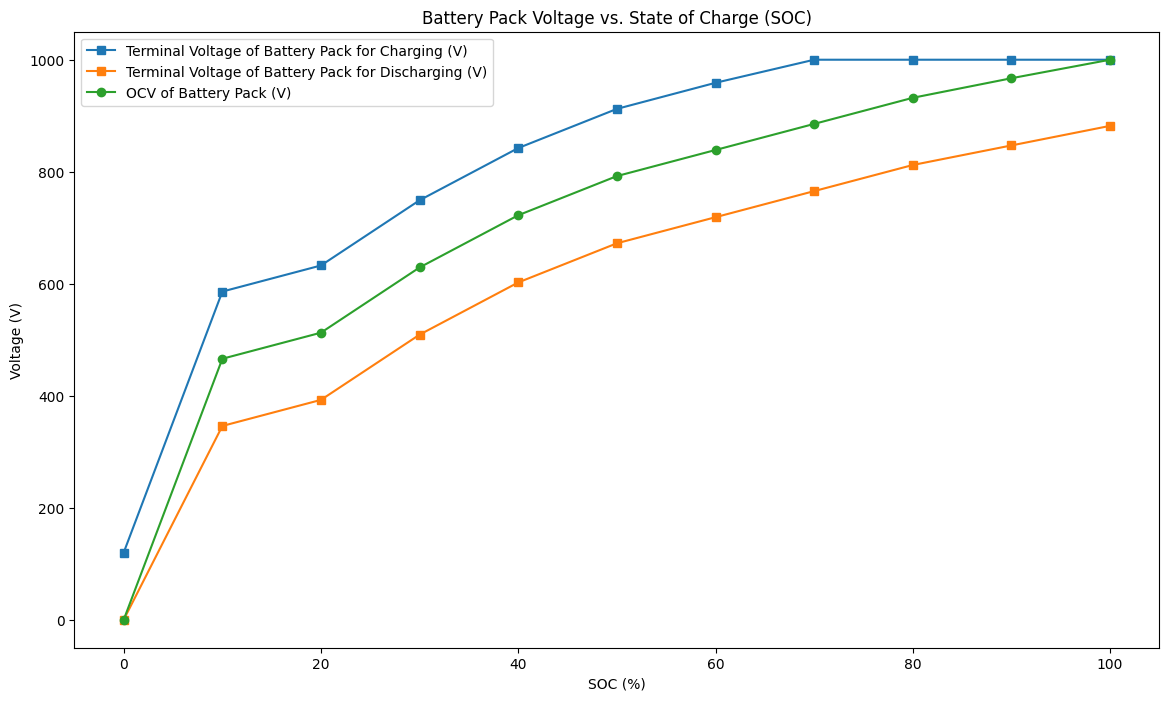

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Define the data from the table provided by the user
soc_percentages = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
ocv_cell_voltages = [0, 2, 2.2, 2.7, 3.1, 3.4, 3.6, 3.8, 4, 4.15, 4.3]

# Calculate OCV of the battery pack for each SOC
ocv_pack_voltages = [ocv * 233 for ocv in ocv_cell_voltages]

# Calculate terminal voltage during charging and discharging
terminal_voltage_charging = [ocv_pack + 120 for ocv_pack in ocv_pack_voltages]
terminal_voltage_discharging = [ocv_pack - 120 for ocv_pack in ocv_pack_voltages]

# Create a DataFrame for the data before capping
df_uncapped = pd.DataFrame({
    'SOC (%)': soc_percentages,
    'OCV Cell (V)': ocv_cell_voltages,
    'OCV Pack (V)': ocv_pack_voltages,
    'Terminal Voltage Charging (V)': terminal_voltage_charging,
    'Terminal Voltage Discharging (V)': terminal_voltage_discharging
})

# Print the calculated values before capping
print("Before capping:")
print(df_uncapped.to_string(index=False))

# Cap the OCV and terminal voltages such that they do not exceed 1000V and do not go below 0V
ocv_pack_voltages_capped = [min(ocv, 1000) for ocv in ocv_pack_voltages]
terminal_voltage_charging_capped = [min(voltage, 1000) for voltage in terminal_voltage_charging]
terminal_voltage_discharging_capped = [max(0, min(voltage, 1000)) for voltage in terminal_voltage_discharging]

# Create a DataFrame for the data after capping
df_capped = pd.DataFrame({
    'SOC (%)': soc_percentages,
    'OCV Cell (V)': ocv_cell_voltages,
    'OCV Pack (V)': ocv_pack_voltages_capped,
    'Terminal Voltage Charging (V)': terminal_voltage_charging_capped,
    'Terminal Voltage Discharging (V)': terminal_voltage_discharging_capped
})

# Print the calculated values after capping
print("\nAfter capping:")
print(df_capped.to_string(index=False))

# Plot the capped data
plt.figure(figsize=(14, 8))

# Plot each capped voltage against SOC

plt.plot('SOC (%)', 'Terminal Voltage Charging (V)', data=df_capped, marker='s', label='Terminal Voltage of Battery Pack for Charging (V)')
plt.plot('SOC (%)', 'Terminal Voltage Discharging (V)', data=df_capped, marker='s', label='Terminal Voltage of Battery Pack for Discharging (V)')
plt.plot('SOC (%)', 'OCV Pack (V)', data=df_capped, marker='o', label='OCV of Battery Pack (V)')
# Adding titles and labels
plt.title('Battery Pack Voltage vs. State of Charge (SOC)')
plt.xlabel('SOC (%)')
plt.ylabel('Voltage (V)')
plt.legend()


# Show the plot
plt.show()


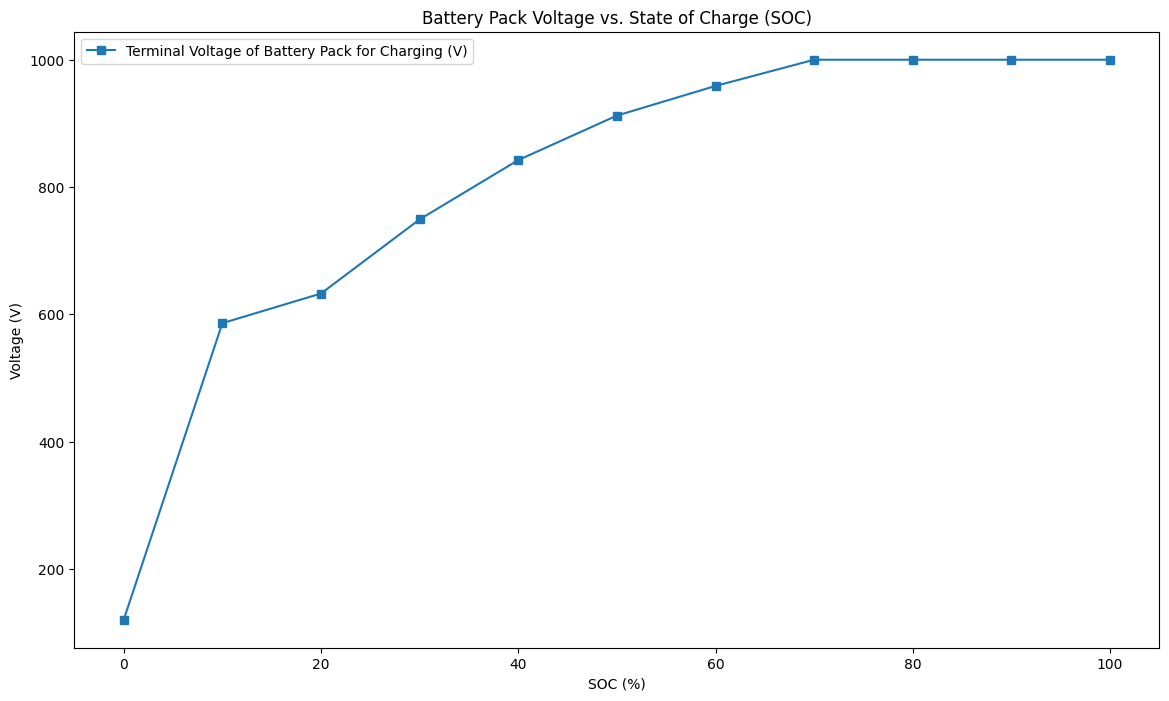

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Define the data from the table provided by the user
soc_percentages = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
ocv_cell_voltages = [0, 2, 2.2, 2.7, 3.1, 3.4, 3.6, 3.8, 4, 4.15, 4.3]

# Calculate OCV of the battery pack for each SOC
ocv_pack_voltages = [ocv * 233 for ocv in ocv_cell_voltages]

# Calculate terminal voltage during charging and discharging
terminal_voltage_charging = [ocv_pack + 120 for ocv_pack in ocv_pack_voltages]
terminal_voltage_discharging = [ocv_pack - 120 for ocv_pack in ocv_pack_voltages]

# Create a DataFrame for the data before capping
df_uncapped = pd.DataFrame({
    'SOC (%)': soc_percentages,
    'OCV Cell (V)': ocv_cell_voltages,
    'OCV Pack (V)': ocv_pack_voltages,
    'Terminal Voltage Charging (V)': terminal_voltage_charging,
    'Terminal Voltage Discharging (V)': terminal_voltage_discharging
})




# Cap the OCV and terminal voltages such that they do not exceed 1000V and do not go below 0V
ocv_pack_voltages_capped = [min(ocv, 1000) for ocv in ocv_pack_voltages]
terminal_voltage_charging_capped = [min(voltage, 1000) for voltage in terminal_voltage_charging]
terminal_voltage_discharging_capped = [max(0, min(voltage, 1000)) for voltage in terminal_voltage_discharging]

# Create a DataFrame for the data after capping
df_capped = pd.DataFrame({
    'SOC (%)': soc_percentages,
    'OCV Cell (V)': ocv_cell_voltages,
    'OCV Pack (V)': ocv_pack_voltages_capped,
    'Terminal Voltage Charging (V)': terminal_voltage_charging_capped,
    'Terminal Voltage Discharging (V)': terminal_voltage_discharging_capped
})

# Print the calculated values after capping


# Plot the capped data
plt.figure(figsize=(14, 8))

# Plot each capped voltage against SOC

plt.plot('SOC (%)', 'Terminal Voltage Charging (V)', data=df_capped, marker='s', label='Terminal Voltage of Battery Pack for Charging (V)')

plt.title('Battery Pack Voltage vs. State of Charge (SOC)')
plt.xlabel('SOC (%)')
plt.ylabel('Voltage (V)')
plt.legend()


# Show the plot
plt.show()


In [ ]:
import cmath

# Given data
V1 = cmath.rect(1.0, 0)    # Slack bus voltage
S2_perunit = 0.3 + 0j      # Complex power injection at bus 2 (per-unit)
S3_perunit = 0.8 + 0j      # Complex power injection at bus 3 (per-unit)
Z12 = 0.2j                 # Impedance between bus 1 and bus 2
Z23 = 0.2j                 # Impedance between bus 2 and bus 3
epsilon = 0.001            # Convergence criterion

# Define functions
def calculate_injections(V2, V3):
    # Bus 2 parameters
    P2 = S2_perunit.real
    Q2 = S2_perunit.imag
    G2, B2 = 0, -5
    G12, B12 = 0, 5

    # Bus 3 parameters
    P3 = S3_perunit.real
    Q3 = S3_perunit.imag
    G3, B3 = 0, -5
    G23, B23 = 0, 5

    return P2, Q2, P3, Q3, G2, B2, G12, B12, G3, B3, G23, B23

def update_voltage_at_bus2(V1, P2, Q2, G12, B12, Z12):
    V2 = V1 - (P2 + Q2 * 1j) * Z12.conjugate()
    return V2

def update_voltage_at_bus3(V2, P3, Q3, G23, B23, Z23):
    V3 = V2 - (P3 + Q3 * 1j) * Z23.conjugate()
    return V3

def gauss_seidel_load_flow(V1, S2_perunit, S3_perunit, Z12, Z23, epsilon):
    # Initial guesses for voltages
    V2 = cmath.rect(1.0, 0)
    V3 = cmath.rect(1.0, 0)

    # Iterate until convergence
    iteration_count = 0  # Initialize iteration count

    while True:
        # Calculate complex power injections at each bus
        P2, Q2, P3, Q3, G2, B2, G12, B12, G3, B3, G23, B23 = calculate_injections(V2, V3)

        # Update voltage at bus 2
        V2_new = update_voltage_at_bus2(V1, P2, Q2, G12, B12, Z12)

        # Update voltage at bus 3
        V3_new = update_voltage_at_bus3(V2_new, P3, Q3, G23, B23, Z23)

        # Check for convergence
        if abs(V2_new - V2) < epsilon and abs(V3_new - V3) < epsilon:
            break

        # Update voltages for next iteration
        V2, V3 = V2_new, V3_new

        iteration_count += 1  # Increment iteration count

    # Print the number of iterations required for convergence
    print("Number of iterations required for convergence:", iteration_count)

    return V2, V3

# Perform load flow analysis
V2, V3 = gauss_seidel_load_flow(V1, S2_perunit, S3_perunit, Z12, Z23, epsilon)

# Display results
print("Voltage magnitude and phase angle at bus 2:", cmath.polar(V2))
print("Voltage magnitude and phase angle at bus 3:", cmath.polar(V3))


Number of iterations required for convergence: 1
Voltage magnitude and phase angle at bus 2: (1.0017983829094554, 0.05992815512120788)
Voltage magnitude and phase angle at bus 3: (1.0239140588936164, 0.2165503049760893)


In [ ]:
import numpy as np

# System Parameters
Ybus = np.array([[5j, -5j, 0],
                 [-5j, 10j, -5j],
                 [0, -5j, 5j]])

P2 = 0.3  # Real power at bus 2
S3 = 0.8 + 0j  # Complex power at bus 3
V = np.array([1.0 + 0j, 1.0 + 0j, 1.0 + 0j])  # Initial voltage guess
tolerance = 0.001
max_iterations = 100

# Reactive power range for experimentation
Q2_values = np.linspace(0, 1.0, 21)  # Adjusted range from 0 to 1.0 in steps of 0.05

# Gauss-Seidel with Reactive Power Exploration
for Q2 in Q2_values:
    S = np.array([0, P2 + Q2 * 1j, S3])  # Update reactive power at bus 2
    V_old = V.copy()  # Initialize for convergence check

    # Iterate over maximum allowed iterations
    for iteration in range(max_iterations):

        # Update voltages for buses 2 and 3
        for i in range(1, len(V)):
            summation = 0
            for j in range(len(V)):
                if j != i:
                    summation += Ybus[i][j] * V[j]
            V[i] = (1 / Ybus[i][i]) * ((S[i] / V[i].conjugate()) - summation)

        # Check for convergence
        max_change = np.max(np.abs(V - V_old))
        if max_change < tolerance:
            print(f"Converged in {iteration} iterations for Q2 = {Q2}")
            break

        V_old = V.copy()

    # Print final voltages for each bus
    print(f"Final Voltages for Q2 = {Q2}:")
    for i in range(len(V)):
        print(f"Bus {i+1}: {V[i]} ({np.abs(V[i])} pu, {np.angle(V[i], deg=True)} deg)")


Converged in 13 iterations for Q2 = 0.0
Final Voltages for Q2 = 0.0:
Bus 1: (1+0j) (1.0 pu, 0.0 deg)
Bus 2: (0.9159087002782735-0.21931223738753475j) (0.9417996627273567 pu, -13.465808861043435 deg)
Bus 3: (0.8457157699589577-0.3770678913380816j) (0.925967255487698 pu, -24.030014280294584 deg)
Converged in 4 iterations for Q2 = 0.05
Final Voltages for Q2 = 0.05:
Bus 1: (1+0j) (1.0 pu, 0.0 deg)
Bus 2: (0.9257280121772526-0.22063296009465008j) (0.9516571103132552 pu, -13.40547248364156 deg)
Bus 3: (0.8567065368873629-0.37713494029303124j) (0.9360431899946534 pu, -23.75980704946447 deg)
Converged in 5 iterations for Q2 = 0.1
Final Voltages for Q2 = 0.1:
Bus 1: (1+0j) (1.0 pu, 0.0 deg)
Bus 2: (0.9383389742592642-0.22059381657602947j) (0.9639199461187152 pu, -13.22942089663307 deg)
Bus 3: (0.8714861133079531-0.3754906779532737j) (0.9489369288411172 pu, -23.30939747834514 deg)
Converged in 5 iterations for Q2 = 0.15000000000000002
Final Voltages for Q2 = 0.15000000000000002:
Bus 1: (1+0j) (1

In [ ]:
# Define the results
results = [
    (0.0, 13, (0.942, -13.47), (0.926, -24.03)),
    (0.05, 4, (0.952, -13.41), (0.936, -23.76)),
    (0.1, 5, (0.964, -13.23), (0.949, -23.31)),
    (0.15, 5, (0.976, -13.06), (0.961, -22.89)),
    (0.2, 5, (0.987, -12.91), (0.973, -22.50)),
    (0.25, 4, (0.998, -12.78), (0.985, -22.16)),
    (0.3, 4, (1.009, -12.64), (0.996, -21.81)),
    (0.35, 4, (1.019, -12.51), (1.007, -21.48)),
    (0.4, 4, (1.030, -12.38), (1.017, -21.17)),
    (0.45, 4, (1.040, -12.25), (1.028, -20.87)),
    (0.5, 4, (1.050, -12.14), (1.038, -20.58)),
    (0.55, 4, (1.059, -12.02), (1.048, -20.31)),
    (0.6, 4, (1.069, -11.91), (1.058, -20.05)),
    (0.65, 4, (1.078, -11.81), (1.067, -19.80)),
    (0.7, 3, (1.087, -11.73), (1.076, -19.59)),
    (0.75, 4, (1.097, -11.61), (1.086, -19.34)),
    (0.8, 3, (1.105, -11.53), (1.095, -19.14)),
    (0.85, 3, (1.114, -11.45), (1.103, -18.93)),
    (0.9, 3, (1.122, -11.36), (1.112, -18.73)),
    (0.95, 3, (1.130, -11.27), (1.121, -18.53)),
    (1.0, 3, (1.138, -11.19), (1.129, -18.34))
]

# Print the results in tabular format
print("| Q2 Value | Iterations | Bus 2 Voltage (Mag ∠ Angle) | Bus 3 Voltage (Mag ∠ Angle) |")
print("|----------|------------|-------------------------------|-------------------------------|")
for result in results:
    Q2, iterations, bus2_voltage, bus3_voltage = result
    print(f"| {Q2:8.2f} | {iterations:10d} | {bus2_voltage[0]:.3f} ∠ {bus2_voltage[1]:.2f}° "
          f"| {bus3_voltage[0]:.3f} ∠ {bus3_voltage[1]:.2f}° |")


| Q2 Value | Iterations | Bus 2 Voltage (Mag ∠ Angle) | Bus 3 Voltage (Mag ∠ Angle) |
|----------|------------|-------------------------------|-------------------------------|
|     0.00 |         13 | 0.942 ∠ -13.47° | 0.926 ∠ -24.03° |
|     0.05 |          4 | 0.952 ∠ -13.41° | 0.936 ∠ -23.76° |
|     0.10 |          5 | 0.964 ∠ -13.23° | 0.949 ∠ -23.31° |
|     0.15 |          5 | 0.976 ∠ -13.06° | 0.961 ∠ -22.89° |
|     0.20 |          5 | 0.987 ∠ -12.91° | 0.973 ∠ -22.50° |
|     0.25 |          4 | 0.998 ∠ -12.78° | 0.985 ∠ -22.16° |
|     0.30 |          4 | 1.009 ∠ -12.64° | 0.996 ∠ -21.81° |
|     0.35 |          4 | 1.019 ∠ -12.51° | 1.007 ∠ -21.48° |
|     0.40 |          4 | 1.030 ∠ -12.38° | 1.017 ∠ -21.17° |
|     0.45 |          4 | 1.040 ∠ -12.25° | 1.028 ∠ -20.87° |
|     0.50 |          4 | 1.050 ∠ -12.14° | 1.038 ∠ -20.58° |
|     0.55 |          4 | 1.059 ∠ -12.02° | 1.048 ∠ -20.31° |
|     0.60 |          4 | 1.069 ∠ -11.91° | 1.058 ∠ -20.05° |
|     0.65 |      